
 # BELLABEAT WELLNESS ANALYSIS — Google Collab

 Analyst: Jannu Sai Ritwik

 Tool: Python (Pandas, Matplotlib)

 Date: March 2026


Phase 3: Process & Analyze

Q1: Set up notebook and load data
Importing necessary libraries and loading the core daily activity dataset.

Concept: pd.read_csv(), .shape, .head()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
daily_activity = pd.read_csv('/content/dailyActivity_merged.csv')
print('Dataframe Shape:', daily_activity.shape)

Dataframe Shape: (940, 15)


In [ ]:
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


Q2: Data Cleaning - Check for Nulls and Duplicates

Before analyzing, we must ensure the data is clean and ready for processing.

Concept: .duplicated().sum(), .isnull().sum()

In [ ]:
print('Duplicated rows:', daily_activity.duplicated().sum())
print('\nNulls values per column:')
print(daily_activity.isnull().sum())

Duplicated rows: 0

Nulls values per column:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
dtype: int64


Q3: Data Transformation - Convert Date String to Datetime

Converting the ActivityDate column to datetime format so we can extract days of the week for our analysis.

Concept: pd.to_datetime(), .dt.day_name(), .dt.month_name()

In [ ]:
daily_activity['ActivityDate'] = pd.to_datetime(daily_activity['ActivityDate'])
daily_activity['Day_of_week'] = daily_activity['ActivityDate'].dt.day_name()
daily_activity['Month'] = daily_activity['ActivityDate'].dt.month_name()

print(daily_activity[['ActivityDate', 'Day_of_week', 'Month']].head())

  ActivityDate Day_of_week  Month
0   2016-04-12     Tuesday  April
1   2016-04-13   Wednesday  April
2   2016-04-14    Thursday  April
3   2016-04-15      Friday  April
4   2016-04-16    Saturday  April


Q4: Sanity Check - Calculate Overall Averages

Verifying that Python calculates the exact same overall averages as our SQL queries (approx 7638 steps, 2304 calories, 991 sedentary mins).

Concept: .mean(), round()

In [ ]:
avg_steps = daily_activity['TotalSteps'].mean().round(0)
avg_calories = daily_activity['Calories'].mean().round(0)
avg_sedentary = daily_activity['SedentaryMinutes'].mean().round(0)

print(f"Average Steps: {avg_steps}")
print(f"Average Calories: {avg_calories}")
print(f"Average Sedentary Minutes: {avg_sedentary}")

Average Steps: 7638.0
Average Calories: 2304.0
Average Sedentary Minutes: 991.0


Q5: User Segmentation by Average Daily Steps

Grouping users into four activity categories (Active, Moderate, Light, Sedentary) based on their average daily step count.

Concept: .groupby(), .mean(), CASE WHEN equivalent = pd.cut() or apply()

In [ ]:
#step 1: get average steps for user
user_avg_steps = daily_activity.groupby('Id')['TotalSteps'].mean().reset_index()
user_avg_steps.columns = ['Id', 'avg_steps']
user_avg_steps['avg_steps'] = user_avg_steps['avg_steps'].round(0)

#step 2: Classify each user
def classify_user(steps):
  if steps >= 10000:
    return 'Active'
  elif steps >= 7500:
    return 'Moderate'
  elif steps >= 5000:
    return 'Light'
  else:
    return 'Sedentary'

user_avg_steps['user_segmentation'] = user_avg_steps['avg_steps'].apply(classify_user)

#step 3 : COunt per segment
segment_counts = user_avg_steps['user_segmentation'].value_counts()
print(segment_counts)


user_segmentation
Light        9
Moderate     9
Sedentary    8
Active       7
Name: count, dtype: int64


Q6: Visualization - Average Steps by Day of Week

Building a bar chart to identify peak activity days and visualize when users are most engaged.

Concept: .groupby().mean(), plt.bar(), plt.axhline()

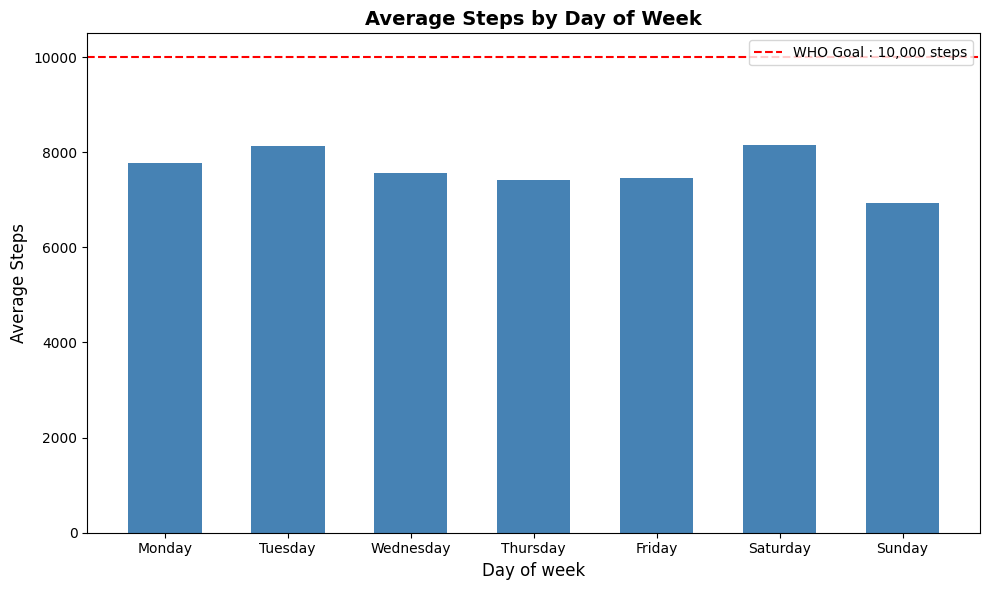

Chart1 saved.


In [ ]:
# Set the correct weeekday order

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
steps_by_day = daily_activity.groupby('Day_of_week')['TotalSteps'].mean().reindex(day_order)

plt.figure(figsize=(10,6))
plt.bar(steps_by_day.index, steps_by_day.values, color = 'steelblue', width = 0.6)
plt.axhline(y = 10000, color = 'red', linestyle = '--', linewidth = 1.5, label = 'WHO Goal : 10,000 steps')
plt.title('Average Steps by Day of Week', fontsize = 14, fontweight = 'bold')
plt.xlabel('Day of week', fontsize = 12)
plt.ylabel('Average Steps', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.savefig('chart1_steps_by_day_of_week.png', dpi = 150)
plt.show()
print('Chart1 saved.')

Q7: Visualization - Time Spent in Each Activity Level

Building a bar chart to compare the average minutes users spend in different activity states.

Concept: .mean(), plt.bar(), multiple columns

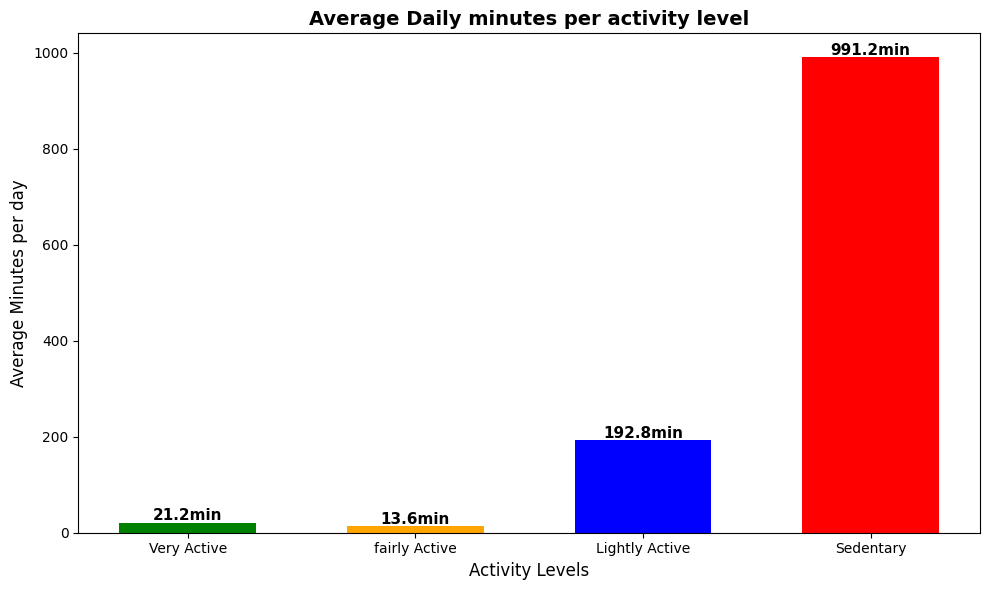

chart2_saved


In [ ]:
activity_cols = ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']
activity_labels = ['Very Active', 'fairly Active', 'Lightly Active', 'Sedentary']

activity_avg = [daily_activity[col].mean().round(1) for col in activity_cols]

colors = ['green', 'orange', 'blue', 'red']

plt.figure(figsize = (10,6))

bars = plt.bar(activity_labels, activity_avg, color = colors, width = 0.6)

for bar, value in zip(bars, activity_avg):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{value}min', ha='center', fontsize=11, fontweight='bold')
plt.title('Average Daily minutes per activity level', fontsize=14, fontweight='bold')
plt.xlabel('Activity Levels', fontsize=12)
plt.ylabel('Average Minutes per day', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_activity_breakdown.png', dpi = 150)
plt.show()
print('chart2_saved')

Q8: Load Sleep Data and Initial Inspection

Loading the `sleepDay_merged.csv` dataset to check its structure and the number of participating users.

Concept: pd.read_csv(), .nunique(), .shape, .head()

In [ ]:
sleep_data = pd.read_csv('/content/sleepDay_merged.csv')
print('Sleep_data Shape:', sleep_data.shape)
print('Unique users with sleep data:', sleep_data.nunique())
print('\nFirst five rows of data:')
print(sleep_data.head())

Sleep_data Shape: (413, 5)
Unique users with sleep data: Id                     24
SleepDay               31
TotalSleepRecords       3
TotalMinutesAsleep    256
TotalTimeInBed        242
dtype: int64

First five rows of data:
           Id               SleepDay  TotalSleepRecords  TotalMinutesAsleep  \
0  1503960366  4/12/2016 12:00:00 AM                  1                 327   
1  1503960366  4/13/2016 12:00:00 AM                  2                 384   
2  1503960366  4/15/2016 12:00:00 AM                  1                 412   
3  1503960366  4/16/2016 12:00:00 AM                  2                 340   
4  1503960366  4/17/2016 12:00:00 AM                  1                 700   

   TotalTimeInBed  
0             346  
1             407  
2             442  
3             367  
4             712  


Q9: Data Transformation - Convert Sleep Minutes to Hours

Converting the total minutes asleep into hours to calculate the overall average sleep duration.


Concept: creating new column from existing, .mean()

In [ ]:
sleep_data['sleep_hours'] = sleep_data['TotalMinutesAsleep'] / 60
sleep_data['sleep_hours'] = sleep_data['sleep_hours'].round(2)

avg_sleep = sleep_data['sleep_hours'].mean().round(2)
print(f"Average sleep hours per night: {avg_sleep}")

Average sleep hours per night: 6.99


Q10: Visualization - Average Sleep by Day of Week

Building a bar chart to identify which days users get the most and least sleep, compared to the 7-hour recommendation.

Concept: pd.to_datetime(), .dt.day_name(), .groupby(), plt.bar()

/tmp/ipykernel_1092/4096013803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'])


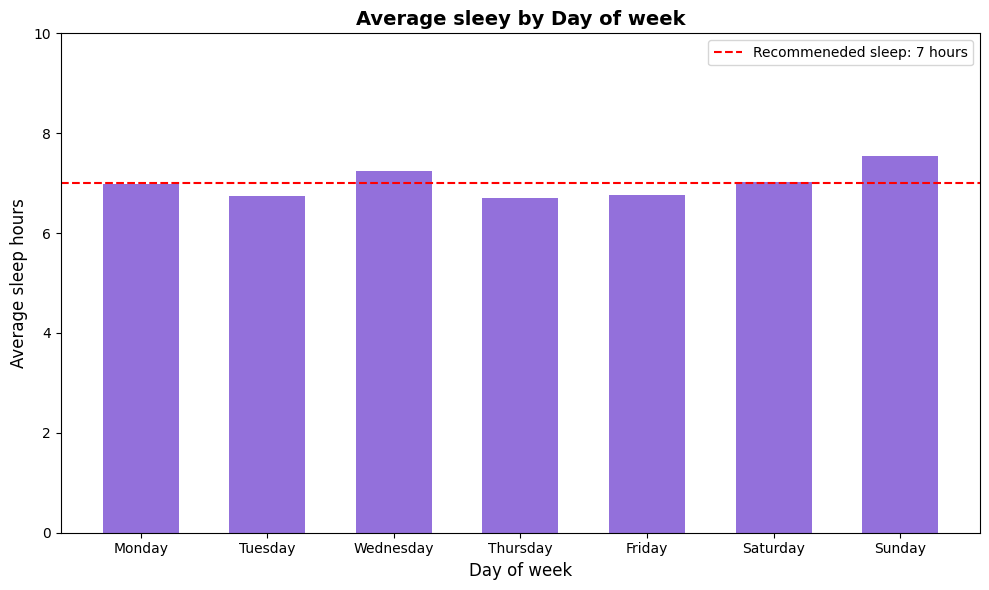

chart3 saved.


In [ ]:
sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'])
sleep_data['day_of_week'] = sleep_data['SleepDay'].dt.day_name()

sleep_by_day = sleep_data.groupby('day_of_week')['sleep_hours'].mean().reindex(day_order)

plt.figure(figsize=(10,6))
plt.bar(sleep_by_day.index, sleep_by_day.values, color='mediumpurple', width=0.6)
plt.axhline(y=7, color = 'red', linestyle = '--', linewidth = 1.5, label = 'Recommeneded sleep: 7 hours')
plt.ylim(0,10)
plt.title('Average sleey by Day of week', fontsize = 14, fontweight = 'bold')
plt.xlabel('Day of week', fontsize = 12)
plt.ylabel('Average sleep hours', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.savefig('chart3_sleep_by_day_of_week.png', dpi = 150)
plt.show()
print('chart3 saved.')


Q11: Load and Prep Hourly Data

Loading the hourly steps dataset and extracting the specific hour of the day for analysis.

Concept: pd.to_datetime(), .dt.hour

In [ ]:
hourly_steps = pd.read_csv('/content/hourlySteps_merged.csv')

hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'], format = '%m/%d/%Y %I:%M:%S %p')
hourly_steps['hour_of_day'] = hourly_steps['ActivityHour'].dt.hour

print('Shape of Hourly_steps:', hourly_steps.shape)
print(hourly_steps[['ActivityHour','hour_of_day', 'StepTotal']].head())

Shape of Hourly_steps: (22099, 4)
         ActivityHour  hour_of_day  StepTotal
0 2016-04-12 00:00:00            0        373
1 2016-04-12 01:00:00            1        160
2 2016-04-12 02:00:00            2        151
3 2016-04-12 03:00:00            3          0
4 2016-04-12 04:00:00            4          0


Q12: Visualization - Average Steps by Hour of Day

Building a line chart to identify peak activity hours and determine the best times for push notifications.

Concept: .groupby(), .mean(), plt.plot()

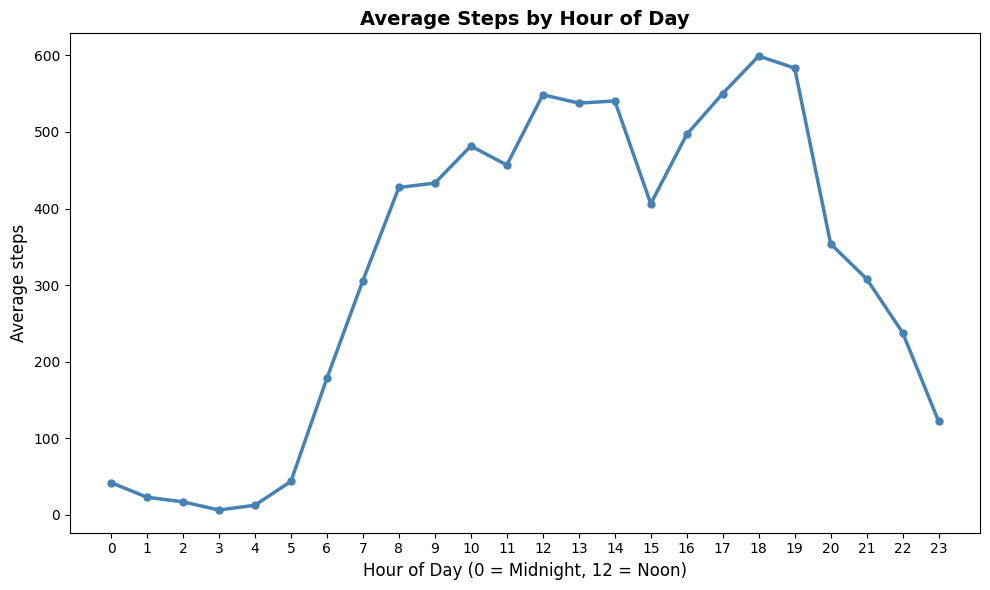

Chart 4 saved.


In [ ]:
steps_by_hour = hourly_steps.groupby('hour_of_day')['StepTotal'].mean()

plt.figure(figsize=(10,6))
plt.plot(steps_by_hour.index, steps_by_hour.values, color='steelblue', linewidth=2.5, marker='o', markersize=5)
plt.title('Average Steps by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
plt.ylabel('Average steps', fontsize=12)
plt.xticks(range(0,24))
plt.tight_layout()
plt.savefig('chart4_steps_by_hour_of_day.png', dpi = 150)
plt.show()
print('Chart 4 saved.')

Q13: Data Engineering - Merge Activity and Sleep Data

Merging the daily activity and sleep datasets using an inner join on User Id and Date to analyze correlations.

Concept: pd.merge(), on=, how=

In [ ]:
daily_activity['date'] = daily_activity['ActivityDate'].dt.date
sleep_data['date'] = sleep_data['SleepDay'].dt.date

merged_Data = pd.merge(daily_activity, sleep_data[['Id', 'date', 'sleep_hours']], on=['Id','date'], how='inner')

print('Merged Data Shape:', merged_Data.shape)
print(f"users in merged_Data: {merged_Data['Id'].nunique()}")

Merged Data Shape: (413, 19)
users in merged_Data: 24


Q14: Visualization - Total Steps vs. Sleep Hours

Building a scatter plot to analyze if there is a correlation between the number of steps taken in a day and the hours of sleep recorded that night.

Concept: plt.scatter()

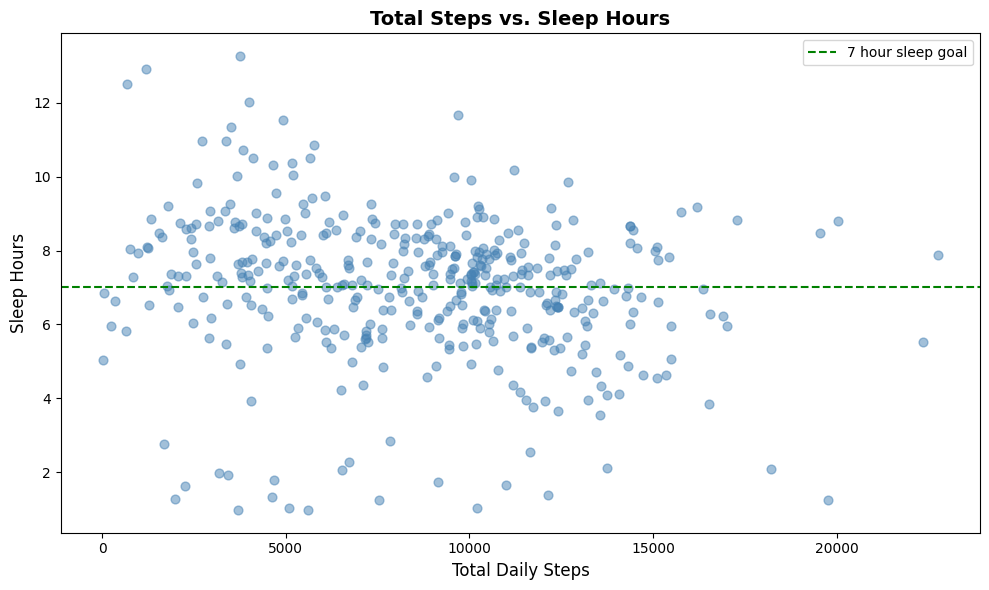

chart 5 saved.


In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(merged_Data['TotalSteps'], merged_Data['sleep_hours'], color='steelblue', alpha=0.5, s=40)
plt.title('Total Steps vs. Sleep Hours', fontsize=14, fontweight='bold')
plt.xlabel('Total Daily Steps', fontsize=12)
plt.ylabel('Sleep Hours', fontsize=12)
plt.axhline(y=7, color = 'green', linestyle='--', linewidth=1.5, label='7 hour sleep goal')
plt.legend()
plt.tight_layout()
plt.savefig('chart5_steps_vs_sleep.png', dpi = 150)
plt.show()
print('chart 5 saved.')


In [ ]:
# Export cleaned files for Power BI
daily_activity.to_csv('powerbi_activity.csv', index=False)
sleep_data.to_csv('powerbi_sleep.csv', index=False)

print("Files exported successfully")
print(f"Activity rows: {len(daily_activity)}")
print(f"Sleep rows: {len(sleep_data)}")

Files exported successfully
Activity rows: 940
Sleep rows: 413


In [ ]:
# Export hourly steps for Power BI
hourly_steps.to_csv('powerbi_hourly.csv', index=False)
print("Hourly file exported successfully")

Hourly file exported successfully
